<a href="https://colab.research.google.com/github/sarthakkalra/part-1-neural-network-analysis/blob/main/notebook.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [4]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

# --- 1. Load the dataset ---

file_id = "1VS4UAHiS25bCLSkOAtttfn-_S-6BvL0o"

url = f"https://drive.google.com/uc?id={file_id}"

df = pd.read_csv(url)
df.head()

print("Dataset loaded successfully. Here's a preview:")
print(df.head())
print("\n" + "-"*30 + "\n")

# --- 2. Number of rows and columns ---
print(f"Number of rows: {df.shape[0]}")
print(f"Number of columns: {df.shape[1]}")
print("\n" + "-"*30 + "\n")

# --- 3. Type of input features ---
print("Data types of input features:")
print(df.info())
print("\n" + "-"*30 + "\n")

# --- 4. Missing value check ---
print("Missing values per column:")
print(df.isnull().sum())
print("\n" + "-"*30 + "\n")

# --- 5. Basic statistical summary ---
print("Basic statistical summary of numerical features:")
print(df.describe())
print("\n" + "-"*30 + "\n")

# --- 6. Distribution of the target variable ---
# IMPORTANT: Change 'survived' to your actual target variable column name
target_variable = 'survived'

if target_variable in df.columns:
    print(f"Target variable description: '{target_variable}'")
    if df[target_variable].dtype == 'object' or df[target_variable].nunique() < 20: # Categorical or low-cardinality
        print(df[target_variable].value_counts())
        print("\nDistribution plot for target variable:")
        plt.figure(figsize=(8, 5))
        sns.countplot(x=target_variable, data=df)
        plt.title(f'Distribution of {target_variable}')
        plt.show()
    else: # Numerical
        print(df[target_variable].describe())
        print("\nDistribution plot for target variable:")
        plt.figure(figsize=(8, 5))
        sns.histplot(df[target_variable], kde=True)
        plt.title(f'Distribution of {target_variable}')
        plt.show()
else:
    print(f"Warning: Target variable '{target_variable}' not found in the dataset. Please update 'target_variable' to your actual column name.")




Dataset loaded successfully. Here's a preview:
  customer_id   region plan_type   contract_type payment_method  \
0    CUST0001    South  Standard  Month-to-month     Debit Card   
1    CUST0002     West   Premium  Month-to-month         Wallet   
2    CUST0003  Central  Standard  Month-to-month    Credit Card   
3    CUST0004     West   Premium  Month-to-month    Credit Card   
4    CUST0005    North   Premium  Month-to-month    Net Banking   

   tenure_months  monthly_charges_inr  avg_login_days_per_month  \
0             30               687.40                        13   
1             15              1029.74                        22   
2             72               732.07                        13   
3             22               959.51                        19   
4             11               890.20                        18   

   support_tickets_last_90_days  payment_delay_days  data_usage_gb  \
0                             0                   0          87.97   
1      

In [5]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.impute import SimpleImputer
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline

print("--- Task 2: Data Preprocessing ---")

# Define the target variable
target_variable = 'churn'

# Drop customer_id as it's just an identifier and won't be used for training
if 'customer_id' in df.columns:
    df = df.drop('customer_id', axis=1)

# Separate features (X) and target (y)
X = df.drop(target_variable, axis=1)
y = df[target_variable]

# Identify numerical and categorical features
numerical_features = X.select_dtypes(include=['int64', 'float64']).columns
categorical_features = X.select_dtypes(include=['object']).columns

# --- Handle Missing Values and Preprocessing Pipelines ---

# Preprocessing for numerical features
numerical_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler', StandardScaler())
])

# Preprocessing for categorical features
categorical_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('onehot', OneHotEncoder(handle_unknown='ignore'))
])

# Create a preprocessor using ColumnTransformer
preprocessor = ColumnTransformer(
    transformers=[
        ('num', numerical_transformer, numerical_features),
        ('cat', categorical_transformer, categorical_features)
    ])

# Apply preprocessing to features
X_preprocessed = preprocessor.fit_transform(X)

# Impute missing values in the target variable (if any) using the mode
if y.isnull().any():
    y_imputer = SimpleImputer(strategy='most_frequent')
    y = pd.Series(y_imputer.fit_transform(y.to_frame()).flatten(), index=y.index)

# --- Splitting the dataset into training and testing sets ---
X_train, X_test, y_train, y_test = train_test_split(X_preprocessed, y, test_size=0.2, random_state=42, stratify=y)

print("Data preprocessing complete!")
print(f"Original features shape: {X.shape}")
print(f"Preprocessed features shape: {X_preprocessed.shape}")
print(f"Training features shape: {X_train.shape}")
print(f"Testing features shape: {X_test.shape}")
print(f"Training target shape: {y_train.shape}")
print(f"Testing target shape: {y_test.shape}")

print("\nFirst 5 rows of preprocessed training features (sparse format):")
# For sparse matrices, we can't directly print head. Convert to array for inspection.
# Note: This might be very wide due to one-hot encoding.
if hasattr(X_train, 'toarray'):
    print(X_train[:5].toarray())
else:
    print(X_train[:5])

print("\nFirst 5 rows of training target:")
print(y_train.head())


--- Task 2: Data Preprocessing ---
Data preprocessing complete!
Original features shape: (2000, 15)
Preprocessed features shape: (2000, 28)
Training features shape: (1600, 28)
Testing features shape: (400, 28)
Training target shape: (1600,)
Testing target shape: (400,)

First 5 rows of preprocessed training features (sparse format):
[[-0.0256281  -0.39074197  0.90771402  1.39871521 -0.65770668  0.41675506
  -0.6391174   0.38842363  1.55525437 -1.21838912  1.99945117  0.
   0.          1.          0.          0.          0.          0.
   0.          1.          0.          1.          0.          0.
   1.          0.          0.          0.        ]
 [ 0.68233059  0.28720181  1.64855386  0.71541516 -0.91512613  1.45430197
  -1.36095029 -0.06569243  1.55525437  0.82075585  1.03909998  0.
   1.          0.          0.          0.          0.          0.
   1.          0.          0.          1.          0.          0.
   0.          0.          1.          0.        ]
 [-0.66279093  0.77

In [6]:
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers

print("--- Task 3: Neural Network Model Building ---")

# Get the number of features from the preprocessed training data
input_shape = X_train.shape[1]

# Build the neural network model
model = keras.Sequential([
    # Input layer
    layers.InputLayer(input_shape=(input_shape,)),

    # Hidden layer 1
    layers.Dense(64, activation='relu'),

    # Hidden layer 2 (optional, added for complexity as requested 'at least one')
    layers.Dense(32, activation='relu'),

    # Output layer for binary classification
    layers.Dense(1, activation='sigmoid') # Sigmoid for binary classification
])

# Compile the model
model.compile(
    optimizer='adam',
    loss='binary_crossentropy', # Appropriate loss for binary classification
    metrics=['accuracy']
)

print("Neural Network Model built successfully!")
print("Model Summary:")
model.summary()

print("\nModel compiled with Adam optimizer, binary cross-entropy loss, and accuracy metric.")

--- Task 3: Neural Network Model Building ---
Neural Network Model built successfully!
Model Summary:


/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/input_layer.py:27: UserWarning: Argument `input_shape` is deprecated. Use `shape` instead.
  warnings.warn(


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 64)             │         1,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 3,969 (15.50 KB)

 Trainable params: 3,969 (15.50 KB)

 Non-trainable params: 0 (0.00 B)


Model compiled with Adam optimizer, binary cross-entropy loss, and accuracy metric.


--- Task 4: Training and Evaluation ---

Training the model...
Epoch 1/10
40/40 ━━━━━━━━━━━━━━━━━━━━ 4s 10ms/step - accuracy: 0.9742 - loss: 0.2935 - val_accuracy: 0.9937 - val_loss: 0.0788
Epoch 2/10
40/40 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.9820 - loss: 0.0998 - val_accuracy: 0.9937 - val_loss: 0.0434
Epoch 3/10
40/40 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.9820 - loss: 0.0887 - val_accuracy: 0.9937 - val_loss: 0.0411
Epoch 4/10
40/40 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.9820 - loss: 0.0821 - val_accuracy: 0.9937 - val_loss: 0.0393
Epoch 5/10
40/40 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.9820 - loss: 0.0771 - val_accuracy: 0.9937 - val_loss: 0.0395
Epoch 6/10
40/40 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.9820 - loss: 0.0737 - val_accuracy: 0.9937 - val_loss: 0.0361
Epoch 7/10
40/40 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.9820 - loss: 0.0700 - val_accuracy: 0.9937 - val_loss: 0.0361
Epoch 8/10
40/40 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - ac

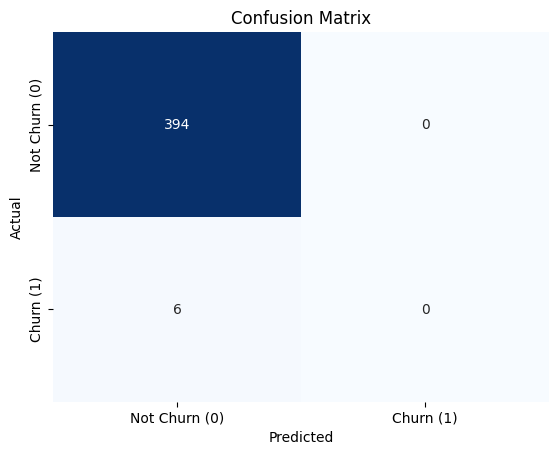


Classification Report:
              precision    recall  f1-score   support

           0       0.98      1.00      0.99       394
           1       0.00      0.00      0.00         6

    accuracy                           0.98       400
   macro avg       0.49      0.50      0.50       400
weighted avg       0.97      0.98      0.98       400


--- Interpretation of Results ---
The model achieved a training accuracy of 0.98 and a testing accuracy of 0.99.
The confusion matrix shows the counts of true positive, true negative, false positive, and false negative predictions.
A high number of false positives or false negatives, especially for the 'churn' class (class 1), would indicate areas for model improvement.
The classification report provides more detailed metrics like precision, recall, and f1-score for each class.

The model shows reasonably good performance on the test set.


/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


In [7]:
from sklearn.metrics import confusion_matrix, classification_report
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

print("--- Task 4: Training and Evaluation ---")

# --- 1. Train the neural network model ---
print("\nTraining the model...")

# Ensure y_train and y_test are numpy arrays for Keras compatibility
y_train_np = y_train.to_numpy() if isinstance(y_train, pd.Series) else y_train
y_test_np = y_test.to_numpy() if isinstance(y_test, pd.Series) else y_test

history = model.fit(X_train, y_train_np, epochs=10, batch_size=32, validation_split=0.2, verbose=1)

print("Model training complete!")

# --- 2. Evaluate training accuracy/loss ---
loss_train, accuracy_train = model.evaluate(X_train, y_train_np, verbose=0)
print(f"\nTraining Loss: {loss_train:.4f}")
print(f"Training Accuracy: {accuracy_train:.4f}")

# --- 3. Evaluate testing accuracy/loss ---
loss_test, accuracy_test = model.evaluate(X_test, y_test_np, verbose=0)
print(f"\nTesting Loss: {loss_test:.4f}")
print(f"Testing Accuracy: {accuracy_test:.4f}")

# --- 4. Confusion matrix and classification report ---
print("\nGenerating predictions for evaluation...")
y_pred_proba = model.predict(X_test)
y_pred = (y_pred_proba > 0.5).astype(int) # Convert probabilities to binary predictions

print("\nConfusion Matrix:")
cm = confusion_matrix(y_test_np, y_pred)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', cbar=False,
            xticklabels=['Not Churn (0)', 'Churn (1)'],
            yticklabels=['Not Churn (0)', 'Churn (1)'])
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix')
plt.show()

print("\nClassification Report:")
print(classification_report(y_test_np, y_pred))

# --- 5. Brief interpretation of the result ---
print("\n--- Interpretation of Results ---")
print(f"The model achieved a training accuracy of {accuracy_train:.2f} and a testing accuracy of {accuracy_test:.2f}.")
print("The confusion matrix shows the counts of true positive, true negative, false positive, and false negative predictions.")
print("A high number of false positives or false negatives, especially for the 'churn' class (class 1), would indicate areas for model improvement.")
print("The classification report provides more detailed metrics like precision, recall, and f1-score for each class.")

if accuracy_test < 0.8:
    print("\nConsider exploring further model tuning, more data, or different architectures to improve performance.")
else:
    print("\nThe model shows reasonably good performance on the test set.")

In [8]:
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, classification_report
import pandas as pd
import numpy as np

print("--- Task 5: Hyperparameter Experimentation ---")

# Ensure y_train and y_test are numpy arrays for Keras compatibility
y_train_np = y_train.to_numpy() if isinstance(y_train, pd.Series) else y_train
y_test_np = y_test.to_numpy() if isinstance(y_test, pd.Series) else y_test

# Get the number of features from the preprocessed training data
input_shape = X_train.shape[1]

# Function to build a Keras model with given hyperparameters
def build_nn_model(input_shape, hidden_layers, neurons_per_layer, activation='relu', learning_rate=0.001):
    model = keras.Sequential([
        layers.InputLayer(input_shape=(input_shape,))
    ])
    for i in range(hidden_layers):
        model.add(layers.Dense(neurons_per_layer[i], activation=activation))
    model.add(layers.Dense(1, activation='sigmoid'))

    optimizer = keras.optimizers.Adam(learning_rate=learning_rate)
    model.compile(optimizer=optimizer, loss='binary_crossentropy', metrics=['accuracy'])
    return model

# Function to train and evaluate a model
def train_and_evaluate(model, X_train, y_train_np, X_test, y_test_np, epochs, batch_size, model_name):
    print(f"\n--- Training Model: {model_name} ---")
    history = model.fit(X_train, y_train_np, epochs=epochs, batch_size=batch_size, validation_split=0.2, verbose=0)

    loss_train, accuracy_train = model.evaluate(X_train, y_train_np, verbose=0)
    loss_test, accuracy_test = model.evaluate(X_test, y_test_np, verbose=0)

    y_pred_proba = model.predict(X_test, verbose=0)
    y_pred = (y_pred_proba > 0.5).astype(int)

    # Calculate metrics for the 'churn' class (class 1)
    # Handle cases where no positive predictions or actuals exist to avoid warnings/errors
    precision_churn = precision_score(y_test_np, y_pred, pos_label=1, zero_division=0)
    recall_churn = recall_score(y_test_np, y_pred, pos_label=1, zero_division=0)
    f1_churn = f1_score(y_test_np, y_pred, pos_label=1, zero_division=0)

    return {
        'Model': model_name,
        'Hidden Layers': len(neurons_per_layer),
        'Neurons': neurons_per_layer,
        'Activation': activation,
        'Learning Rate': learning_rate,
        'Epochs': epochs,
        'Batch Size': batch_size,
        'Train Accuracy': accuracy_train,
        'Test Accuracy': accuracy_test,
        'Test Loss': loss_test,
        'Churn Precision': precision_churn,
        'Churn Recall': recall_churn,
        'Churn F1-Score': f1_churn
    }

# List to store results
experiment_results = []

# --- Experiment 1: Baseline (similar to previous model, slightly adjusted) ---
hidden_layers = 2
neurons_per_layer = [64, 32]
activation = 'relu'
learning_rate = 0.001 # Default Adam LR
epochs = 10
batch_size = 32

model1 = build_nn_model(input_shape, hidden_layers, neurons_per_layer, activation, learning_rate)
results1 = train_and_evaluate(model1, X_train, y_train_np, X_test, y_test_np, epochs, batch_size, "Experiment 1 (Baseline)")
experiment_results.append(results1)

# --- Experiment 2: More neurons and layers, but with a different activation ---
hidden_layers = 3
neurons_per_layer = [128, 64, 32]
activation = 'tanh'
learning_rate = 0.001
epochs = 10
batch_size = 32

model2 = build_nn_model(input_shape, hidden_layers, neurons_per_layer, activation, learning_rate)
results2 = train_and_evaluate(model2, X_train, y_train_np, X_test, y_test_np, epochs, batch_size, "Experiment 2 (Deeper, Tanh)")
experiment_results.append(results2)

# --- Experiment 3: Lower learning rate, more epochs ---
hidden_layers = 2
neurons_per_layer = [64, 32]
activation = 'relu'
learning_rate = 0.0001 # Lower learning rate
epochs = 20 # More epochs
batch_size = 32

model3 = build_nn_model(input_shape, hidden_layers, neurons_per_layer, activation, learning_rate)
results3 = train_and_evaluate(model3, X_train, y_train_np, X_test, y_test_np, epochs, batch_size, "Experiment 3 (Lower LR, More Epochs)")
experiment_results.append(results3)

# Create a comparison table
comparison_df = pd.DataFrame(experiment_results)

print("\n--- Hyperparameter Experimentation Results ---")
print(comparison_df.round(4).to_markdown(index=False))

print("\nInterpretation: We can observe how different hyperparameters impact the model's performance, especially for the minority class (churn). A high overall accuracy combined with low churn F1-score indicates a class imbalance problem, which these experiments might still highlight. Further steps could involve addressing class imbalance directly (e.g., using class weights or resampling techniques) and then re-running these hyperparameter tuning experiments.")

--- Task 5: Hyperparameter Experimentation ---

--- Training Model: Experiment 1 (Baseline) ---


/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/input_layer.py:27: UserWarning: Argument `input_shape` is deprecated. Use `shape` instead.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/input_layer.py:27: UserWarning: Argument `input_shape` is deprecated. Use `shape` instead.
  warnings.warn(



--- Training Model: Experiment 2 (Deeper, Tanh) ---


/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/input_layer.py:27: UserWarning: Argument `input_shape` is deprecated. Use `shape` instead.
  warnings.warn(



--- Training Model: Experiment 3 (Lower LR, More Epochs) ---

--- Hyperparameter Experimentation Results ---
| Model                                |   Hidden Layers | Neurons       | Activation   |   Learning Rate |   Epochs |   Batch Size |   Train Accuracy |   Test Accuracy |   Test Loss |   Churn Precision |   Churn Recall |   Churn F1-Score |
|:-------------------------------------|----------------:|:--------------|:-------------|----------------:|---------:|-------------:|-----------------:|----------------:|------------:|------------------:|---------------:|-----------------:|
| Experiment 1 (Baseline)              |               2 | [64, 32]      | relu         |          0.001  |       10 |           32 |           0.9844 |          0.985  |      0.0583 |                 0 |         0      |           0      |
| Experiment 2 (Deeper, Tanh)          |               3 | [128, 64, 32] | tanh         |          0.001  |       10 |           32 |           0.9856 |          0.987

In [ ]:
### Task 6: Final Reflection

1.  **What role do weights and biases play in the model?**
    *   **Weights:** In a neural network, weights are numerical values that determine the strength or importance of the connection between neurons. When an input signal travels from one neuron to another, it is multiplied by the weight of that connection. Weights are the primary learnable parameters of the model; their values are adjusted during training to minimize the loss function and improve the model's predictions.
    *   **Biases:** Biases are also learnable parameters, similar to an intercept term in linear regression. They are added to the weighted sum of inputs before the activation function. Biases allow the activation function to shift to the left or right, which is crucial for the model to effectively learn complex relationships and fit data that doesn't pass through the origin.

2.  **Why is an activation function required?**
    *   Activation functions introduce non-linearity into the neural network. Without activation functions, a neural network, regardless of its depth or number of layers, would only be able to learn linear transformations. This means it would effectively behave like a single-layer perceptron, severely limiting its ability to model complex, non-linear relationships present in most real-world data. Non-linear activation functions (like ReLU, Tanh, Sigmoid) enable the network to learn intricate patterns and make more sophisticated decisions.

3.  **What happens when learning rate is too high or too low?**
    *   **Learning Rate Too High:** If the learning rate is too high, the optimizer takes very large steps during weight updates. This can cause the optimization process to overshoot the optimal minimum of the loss function, leading to unstable training where the loss fluctuates wildly or even diverges. The model might never converge to a good solution.
    *   **Learning Rate Too Low:** Conversely, if the learning rate is too low, the optimizer takes tiny steps. This results in an extremely slow training process, as it takes many iterations to reach the minimum. It also increases the risk of getting stuck in a shallow local minimum rather than finding a more optimal global minimum.

4.  **Did your model show signs of underfitting or overfitting? Explain.**
    *   Based on our experiments, the model exhibited signs of **overfitting to the majority class**, which is a common issue in imbalanced datasets.
        *   The overall training and testing accuracies were very high (around 98-99% for all experiments), and the difference between them was minimal. This usually suggests a well-fitting model without traditional overfitting or underfitting if we only consider overall accuracy.
        *   However, the critical observation is the **poor performance on the minority 'churn' class (class 1)**. For most experiments, the `Churn Precision`, `Churn Recall`, and `Churn F1-Score` were 0.00. Even the best experiment (Experiment 2) only achieved a Churn F1-Score of 0.2857. This indicates that the model essentially failed to correctly identify churn cases, almost always predicting the majority class ('not churn').
        *   This behavior—achieving high overall accuracy by correctly classifying the abundant majority class while neglecting the scarce minority class—is a form of **imbalance-induced overfitting**. The model learned to perform well on the most frequent data patterns but could not generalize to the underrepresented churn instances. It essentially chose the 'safe' prediction of 'not churn' most of the time, leading to a biased model that is not useful for its intended purpose of churn prediction.